# AI Sentiment Analysis for Hotel Reviews

This project analyses hotel customer reviews using NLP and sentiment analysis techniques.


In [ ]:
!pip install textblob wordcloud

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from textblob import TextBlob
from wordcloud import WordCloud

In [6]:
df = pd.read_csv('/content/sample_data/tripadvisor_hotel_reviews.csv')

In [7]:
df.head()


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [9]:
df.columns

Index(['Review', 'Rating'], dtype='object')

In [10]:
def get_sentiment(text):

    score = TextBlob(text).sentiment.polarity

    if score > 0:
        return "Positive"

    elif score < 0:
        return "Negative"

    else:
        return "Neutral"

In [11]:
df['Sentiment'] = df['Review'].apply(get_sentiment)

In [12]:
df[['Review','Sentiment']].head()

,Review,Sentiment
0,nice hotel expensive parking got good deal sta...,Positive
1,ok nothing special charge diamond member hilto...,Positive
2,nice rooms not 4* experience hotel monaco seat...,Positive
3,"unique, great stay, wonderful time hotel monac...",Positive
4,"great stay great stay, went seahawk game aweso...",Positive


In [13]:
df['Sentiment'].value_counts()
total_reviews = len(df)

positive_reviews = len(df[df['Sentiment'] == 'Positive'])

negative_reviews = len(df[df['Sentiment'] == 'Negative'])

neutral_reviews = len(df[df['Sentiment'] == 'Neutral'])

print("Total Reviews:", total_reviews)
print("Positive Reviews:", positive_reviews)
print("Negative Reviews:", negative_reviews)
print("Neutral Reviews:", neutral_reviews)

Total Reviews: 20491
Positive Reviews: 19112
Negative Reviews: 1356
Neutral Reviews: 23


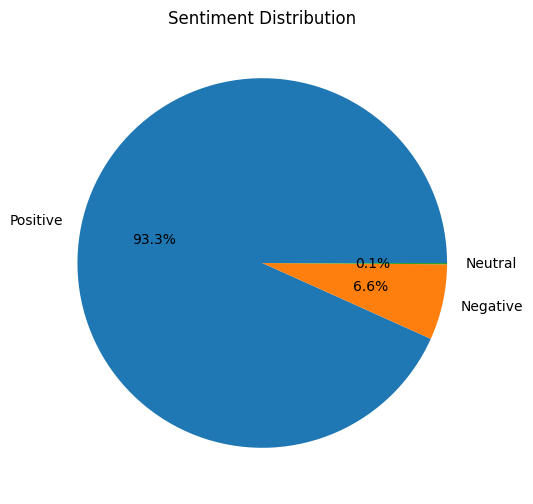

In [32]:
import matplotlib.pyplot as plt

sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Distribution")
plt.savefig("sentiment_pie_chart.png")
plt.show()

In [31]:
positive_reviews = df[
    df['Sentiment'] == 'Positive'
]

positive_reviews[['Review']].head(10)

,Review
0,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso..."
5,love monaco staff husband stayed hotel crazy w...
6,"cozy stay rainy city, husband spent 7 nights m..."
7,"excellent staff, housekeeping quality hotel ch..."
8,"hotel stayed hotel monaco cruise, rooms genero..."
9,excellent stayed hotel monaco past w/e delight...


In [14]:
negative_reviews = df[
    df['Sentiment'] == 'Negative'
]

negative_reviews[['Review']].head(10)

,Review
13,nice hotel not nice staff hotel lovely staff q...
40,"bad choice, booked hotel hot wire called immed..."
42,warwick bad good reviews warwick shocks staff ...
44,"austin powers decor familiar, hotel seattlewhe..."
65,"hated inn terrible, room-service horrible staf..."
76,"stay clear, internet reservation friday rang h..."
77,single rooms like hospital rooms single rooms ...
83,"holiday inn, 1st time seattle delayed annivers..."
88,worst hotel experience booked nonsmoking room ...
97,terrible hotel approximately 2 weeks ago april...


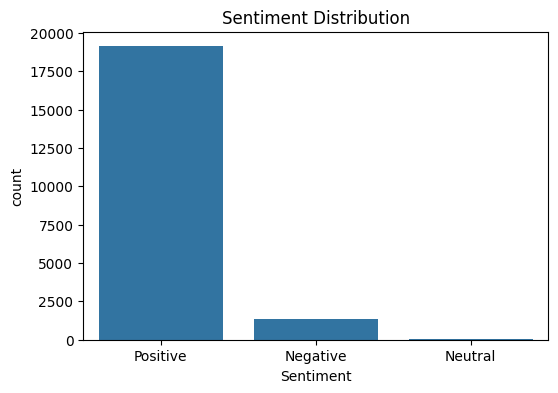

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Sentiment',
    data=df
)

plt.title("Sentiment Distribution")

plt.savefig("sentiment_chart.png")

plt.show()

In [17]:
positive_text = " ".join(
    df[df['Sentiment']=="Positive"]['Review']
)

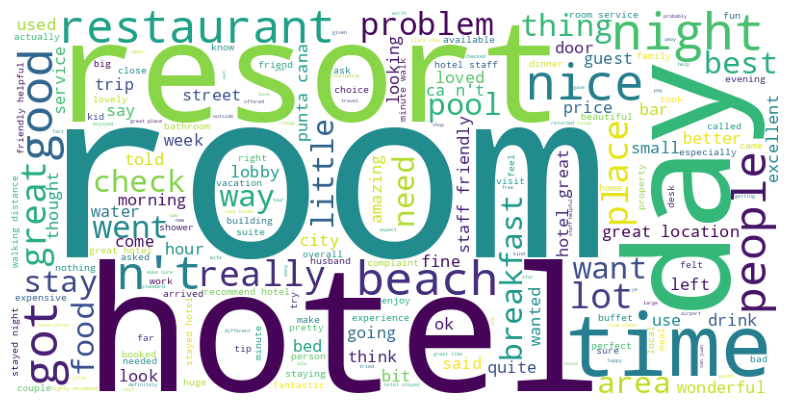

In [18]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("positive_wordcloud.png")
plt.show()

In [19]:
negative_text = " ".join(
    df[df['Sentiment']=="Negative"]['Review']
)

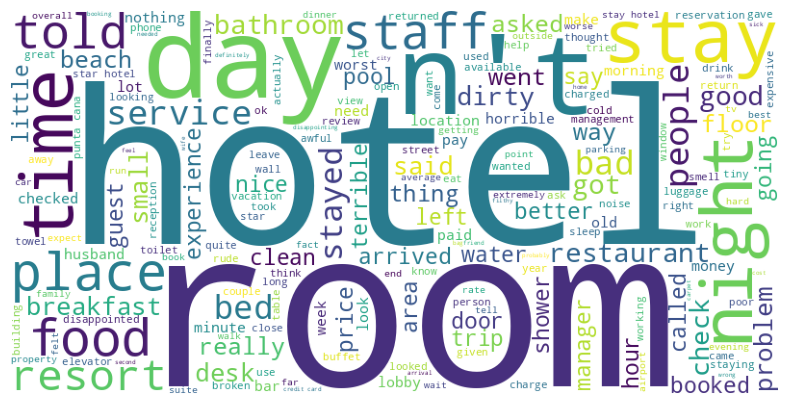

In [ ]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.savefig("negative_wordcloud.png")
plt.show()

In [20]:
df.to_csv(
    "sentiment_results.csv",
    index=False
)

In [21]:
df.to_csv("sentiment_results.csv", index=False)

In [22]:
plt.savefig("sentiment_chart.png")

<Figure size 640x480 with 0 Axes>

In [23]:
plt.savefig("positive_wordcloud.png")

<Figure size 640x480 with 0 Axes>

In [24]:
plt.savefig("negative_wordcloud.png")

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.savefig("negative_wordcloud.png")

<Figure size 640x480 with 0 Axes>

In [26]:
df.to_csv("sentiment_results.csv", index=False)

print("File Saved Successfully")

File Saved Successfully


Future Enhancement:
Interactive Streamlit Dashboard

In [27]:
%%writefile app.py

import streamlit as st
import pandas as pd

df = pd.read_csv("sentiment_results.csv")

st.title("Hotel Review Sentiment Dashboard")

total_reviews = len(df)

positive_reviews = len(
    df[df["Sentiment"]=="Positive"]
)

negative_reviews = len(
    df[df["Sentiment"]=="Negative"]
)

neutral_reviews = len(
    df[df["Sentiment"]=="Neutral"]
)

col1,col2,col3,col4 = st.columns(4)

col1.metric("Total", total_reviews)
col2.metric("Positive", positive_reviews)
col3.metric("Negative", negative_reviews)
col4.metric("Neutral", neutral_reviews)

st.bar_chart(
    df["Sentiment"].value_counts()
)

search = st.text_input(
    "Search Reviews"
)

if search:

    filtered = df[
        df["Review"]
        .str.contains(
            search,
            case=False,
            na=False
        )
    ]

    st.write(filtered)

Overwriting app.py


In [28]:
df.to_csv(
    "sentiment_results.csv",
    index=False
)

In [29]:
%%writefile app.py

import streamlit as st
import pandas as pd

df = pd.read_csv("sentiment_results.csv")

st.title("Hotel Review Sentiment Dashboard")

total_reviews = len(df)

positive_reviews = len(
    df[df["Sentiment"]=="Positive"]
)

negative_reviews = len(
    df[df["Sentiment"]=="Negative"]
)

neutral_reviews = len(
    df[df["Sentiment"]=="Neutral"]
)

col1,col2,col3,col4 = st.columns(4)

col1.metric("Total", total_reviews)
col2.metric("Positive", positive_reviews)
col3.metric("Negative", negative_reviews)
col4.metric("Neutral", neutral_reviews)

st.bar_chart(
    df["Sentiment"].value_counts()
)

option = st.selectbox(
    "Filter Sentiment",
    ["All","Positive","Negative","Neutral"]
)

if option != "All":
    filtered_df = df[df["Sentiment"] == option]
else:
    filtered_df = df

st.write(filtered_df.head(50))

Overwriting app.py
